In [35]:
import locale
def getpreferredencoding(do_setlocale = True):
  return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [36]:
from langchain_community.llms import LlamaCpp
from langchain_core.callbacks import CallbackManager, StreamingStdOutCallbackHandler
from langchain_core.prompts import PromptTemplate
#
n_gpu_layers = -1  # The number of layers to put on the GPU. The rest will be on the CPU. If you don't know how many layers there are, you can use -1 to move all to GPU.
n_batch = 512  # Should be between 1 and n_ctx, consider the amount of VRAM in your GPU.
#
# Callbacks support token-wise streaming
callback_manager = CallbackManager([StreamingStdOutCallbackHandler()])
#
# Make sure the model path is correct for your system!
model = LlamaCpp(
    model_path="/content/zephyr-7b-beta.Q4_K_M.gguf",
    n_gpu_layers=n_gpu_layers,
    n_batch=n_batch,
    temperature=0.75,
    max_tokens=1000,
    top_p=1,
    n_ctx=35000,
    callback_manager=callback_manager,
    verbose=True,  # Verbose is required to pass to the callback manager
)

ImportError: Could not import llama-cpp-python library. Please install the llama-cpp-python library to use this embedding model: pip install llama-cpp-python

In [23]:
from langchain.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
#
EMBEDDING_MODEL_NAME = "thenlper/gte-small"

embd = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},  # set True for cosine similarity
)

In [24]:
import matplotlib.pyplot as plt
import tiktoken
from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader
def num_tokens_from_string(string: str, encoding_name: str) -> int:
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

url = "https://python.langchain.com/docs/expression_language/"
loader = RecursiveUrlLoader(url, max_depth=20, extractor = lambda x: Soup(x, "html.parser").text)
docs = loader.load()
docs_texts = [doc.page_content for doc in docs]


<function matplotlib.pyplot.show(close=None, block=None)>

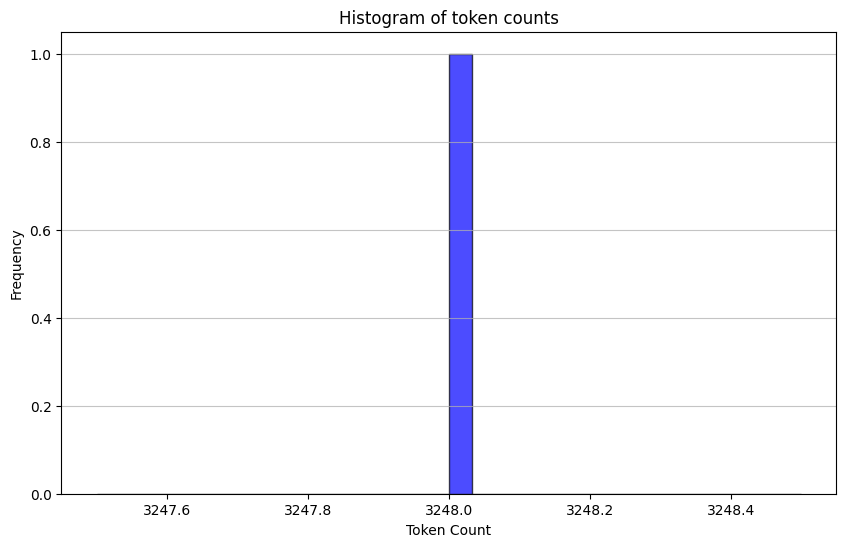

In [25]:
counts = [num_tokens_from_string(doc, "cl100k_base") for doc in docs_texts]

plt.figure(figsize=(10, 6))
plt.hist(counts, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title("Histogram of token counts")
plt.ylabel("Frequency")
plt.xlabel("Token Count")
plt.grid(axis='y', alpha=0.75)
plt.show

In [26]:
d_sorted = sorted(docs, key=lambda x: x.metadata['source'])
d_reversed = list(reversed(d_sorted))
concatenated_content = "\n\n\n --- \n\n\n".join([doc.page_content for doc in d_reversed])
print(f'Num tokens in all context: {num_tokens_from_string(concatenated_content, "cl100k_base")}')

Num tokens in all context: 3248


In [27]:
print(concatenated_content)






LangChain Expression Language (LCEL) | 🦜️🔗 LangChain






Skip to main contentIntegrationsAPI ReferenceMoreContributingPeopleError referenceLangSmithLangGraphLangChain HubLangChain JS/TSv0.3v0.3v0.2v0.1💬SearchIntroductionTutorialsBuild a Question Answering application over a Graph DatabaseTutorialsBuild a simple LLM application with chat models and prompt templatesBuild a ChatbotBuild a Retrieval Augmented Generation (RAG) App: Part 2Build an Extraction ChainBuild an AgentTaggingBuild a Retrieval Augmented Generation (RAG) App: Part 1Build a semantic search engineBuild a Question/Answering system over SQL dataSummarize TextHow-to guidesHow-to guidesHow to use tools in a chainHow to use a vectorstore as a retrieverHow to add memory to chatbotsHow to use example selectorsHow to add a semantic layer over graph databaseHow to invoke runnables in parallelHow to stream chat model responsesHow to add default invocation args to a RunnableHow to add retrieval to chatbotsHow to use few sho

In [28]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

chunk_size = 1000
text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=0)
texts_split = text_splitter.split_text(concatenated_content)
print(f"Num chunks: {len(texts_split)}")


Num chunks: 21


In [29]:
global_embeddings = [embd.embed_query(chunk) for chunk in texts_split]
print(f"Length of 1 global embedding: {len(global_embeddings[0])}")

Length of 1 global embedding: 384


c:\Users\hasee\miniconda3\envs\finetuning_course\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[10.339218  8.37474 ]


<function matplotlib.pyplot.show(close=None, block=None)>

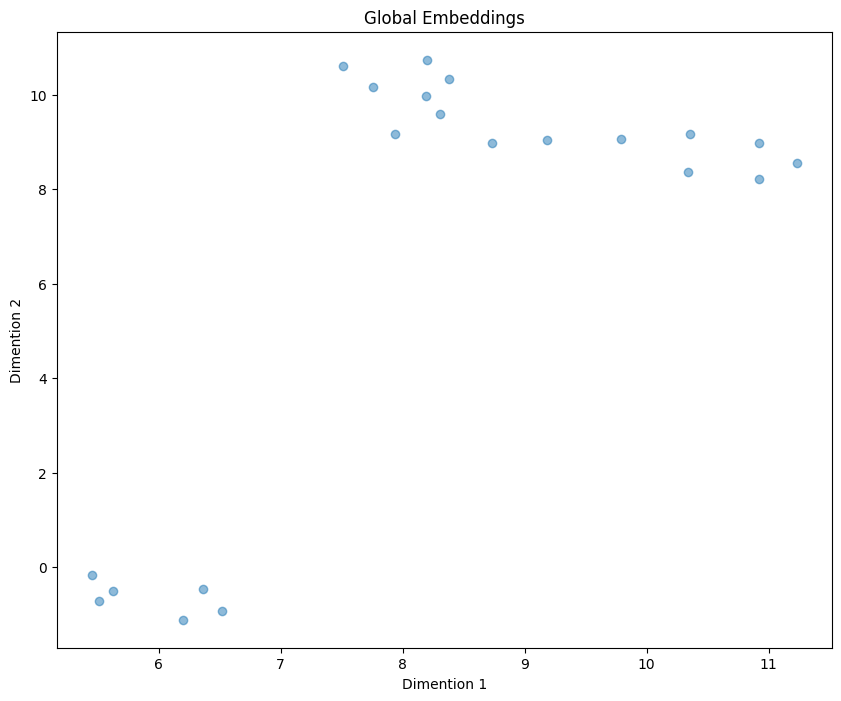

In [30]:
import matplotlib.pyplot as plt
from typing import Optional
import numpy as np
import umap

def reduce_cluster_embeddings(
        embeddings: np.ndarray,
        dim: int,
        n_neighbors: Optional[int]=None,
        metric: str = "cosine",
) -> np.ndarray:
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)
    return umap.UMAP(n_neighbors=n_neighbors, n_components=dim, metric=metric).fit_transform(embeddings)

dim = 2
global_embeddings_reduced = reduce_cluster_embeddings(global_embeddings, dim)
print(global_embeddings_reduced[0])

plt.figure(figsize=(10, 8))
plt.scatter(global_embeddings_reduced[:, 0], global_embeddings_reduced[:, 1], alpha=0.5)
plt.title("Global Embeddings")
plt.xlabel("Dimention 1")
plt.ylabel("Dimention 2")
plt.show

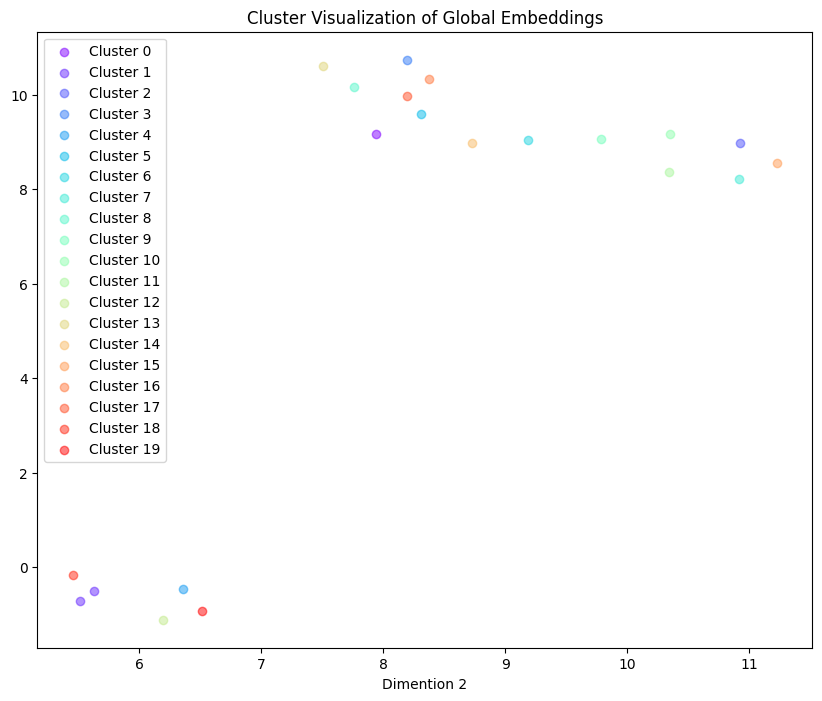

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture

def get_optimal_clusters(embeddings: np.ndarray, max_clusters: int = 50, random_state: int=1234):
    max_clusters = min(max_clusters, len(embeddings))
    bics = [GaussianMixture(n_components=n, random_state=random_state).fit(embeddings).bic(embeddings) for n in range(1, max_clusters)]
    return np.argmin(bics) + 1

def gmm_clustering(embeddings: np.ndarray, threshold: float, random_state: int =0):
    n_clusters = get_optimal_clusters(embeddings=embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state).fit(embeddings)
    probs = gm.predict_proba(embeddings)
    labels = [np.where(prob > threshold)[0] for prob in probs]
    return labels, n_clusters

labels, _ = gmm_clustering(global_embeddings_reduced, threshold=0.5)

plot_labels = np.array([label[0] if len(label) > 0 else -1 for label in labels])
plt.figure(figsize=(10,8))

unique_labels = np.unique(plot_labels)
colors = plt.cm.rainbow(np.linspace(0,1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = plot_labels == label
    plt.scatter(global_embeddings_reduced[mask, 0], global_embeddings_reduced[mask, 1], color=color, label=f'Cluster {label}', alpha=0.5)

plt.title("Cluster Visualization of Global Embeddings")
plt.xlabel("Dimention 1")
plt.xlabel("Dimention 2")
plt.legend()
plt.show()

In [34]:
import pandas as pd

simple_labels = [label[0] if len(label) > 0 else -1 for label in labels]

df = pd.DataFrame({
    'Text': texts_split,
    'Embedding': list(global_embeddings_reduced),
    'Cluster' : simple_labels
})

print(df.head(3))

                                                Text                Embedding  \
0  LangChain Expression Language (LCEL) | 🦜️🔗 Lan...     [10.339218, 8.37474]   
1  Skip to main contentIntegrationsAPI ReferenceM...  [6.362542, -0.45954022]   
2  install LangChain packagesHow to add examples ...   [5.512713, -0.7234964]   

   Cluster  
0       11  
1        4  
2        1  


In [37]:
def foramt_cluster_texts(df):
    clustered_text = {}
    for cluster in df['Cluster'].unique():
        cluster_texts = df[df['Cluster'] == cluster]['Text'].tolist()
        clustered_text[cluster] = "---".join(cluster_texts)
    return clustered_text

print(foramt_cluster_texts(df=df))

{11: 'LangChain Expression Language (LCEL) | 🦜️🔗 LangChain', 4: 'Skip to main contentIntegrationsAPI ReferenceMoreContributingPeopleError referenceLangSmithLangGraphLangChain HubLangChain JS/TSv0.3v0.3v0.2v0.1💬SearchIntroductionTutorialsBuild a Question Answering application over a Graph DatabaseTutorialsBuild a simple LLM application with chat models and prompt templatesBuild a ChatbotBuild a Retrieval Augmented Generation (RAG) App: Part 2Build an Extraction ChainBuild an AgentTaggingBuild a Retrieval Augmented Generation (RAG) App: Part 1Build a semantic search engineBuild a Question/Answering system over SQL dataSummarize TextHow-to guidesHow-to guidesHow to use tools in a chainHow to use a vectorstore as a retrieverHow to add memory to chatbotsHow to use example selectorsHow to add a semantic layer over graph databaseHow to invoke runnables in parallelHow to stream chat model responsesHow to add default invocation args to a RunnableHow to add retrieval to chatbotsHow to use few sh

# Helper Function

In [38]:
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import umap
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from sklearn.mixture import GaussianMixture

RANDOM_SEED = 224

def global_cluster_embeddings(
        embeddings: np.ndarray,
        dim: int,
        n_neighbors: Optional[int] = None,
        metric: str = "cosine",
) -> np.ndarray:
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)
    return umap.UMAP(
        n_neighbors=n_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)

def local_cluster_embeddings(
        embeddings: np.ndarray, dim: int, num_neighbours: int=10, metric: str="cosine"
) -> np.ndarray:
    return umap.UMAP(
        n_neighbors=num_neighbours, n_components=dim, metric=metric).fit_transform(embeddings)

def get_optimal_clusters(
        embeddings: np.ndarray, max_clusters: int=50, random_state: int = RANDOM_SEED, 
) -> int:
    max_clusters = min(max_clusters, len(embeddings))
    n_clusters = np.arrange(1, max_clusters)
    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        bics.append(gm.bic(embeddings))
    return n_clusters[np.argmin(bics)]

def GMM_cluster(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    n_clusters = get_optimal_clusters(embeddings=embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)
    probs = gm.predict(embeddings)
    labels = [np.where(prob>threshold)[0] for prob in probs]
    return labels, n_clusters

def perform_clustering(
        embeddings: np.ndarray,
        dim:int,
        threshold: float,
) -> list[np.ndarray]:
    if len(embeddings) <=dim + 1:
        return [np.array([0]) for _ in range(len(embeddings))]
    
    reduced_embeddings_global = global_cluster_embeddings(embeddings, dim)
    global_clusters, n_global_clusters = GMM_cluster(reduced_embeddings_global, threshold)

    all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
    total_clusters = 0

    for i in range(n_global_clusters):
        global_cluster_embeddings_ = embeddings[np.array([i in gc for gc in global_clusters])]

        if len(global_cluster_embeddings_) == 0:
            continue
        if len(global_cluster_embeddings_) <= dim+1:
            local_clusters = [np.array([0]) for _ in global_cluster_embeddings_]
        else:
            reduced_embeddings_local = local_cluster_embeddings(global_cluster_embeddings_, dim)
            local_clusters, n_local_clusters = GMM_cluster(reduced_embeddings_local, threshold)

        for j in range(n_local_clusters):
            local_cluster_embeddings_ = global_cluster_embeddings_[global_cluster_embeddings_[np.array([j in lc for lc in local_clusters])]]
            indices = np.where(
                embeddings == local_cluster_embeddings_[:, None].all(-1))[1]
            for idx in indices:
                all_local_clusters[idx] = np.append(all_local_clusters[idx], j + total_clusters)
        
        total_clusters += n_local_clusters

    return all_local_clusters

In [ ]:
def embed(texts):
    text_embeddings = embd.embed_documents(texts)
    text_embeddings_np = np.array(text_embeddings)
    return text_embeddings_np

def embed_cluster_texts(texts):
    text_embeddings_np = embed(texts)
    cluster_labels = perform_clustering(text_embeddings_np, 10, 0.1)
    df = pd.DataFrame()
    df["text"] = texts
    df["embd"] = text_embeddings_np
    df["cluster"] = cluster_labels
    return df

def fmt_txt(df: pd.DataFrame) -> str:
    unique_text = df["text"].tolist()
    return "--- ---\n --- ---".join(unique_text)

def embed_cluster_summarize_texts(texts: List[str], level:int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_clusters = embed_cluster_texts(texts)
    expanded_list = []

    for index, row in df_clusters.iterrows():
        for cluster in row["cluster"]:
            expanded_list.append(
                {"text":row["text"], "embd":row["embed"], "cluster":cluster}
            )
    expanded_df = pd.DataFrame(expanded_list)
    all_clusters = expanded_df["Cluster"].unique()
